<a href="https://colab.research.google.com/github/giankev/lightweight-model-for-signal-processing/blob/main/syntethic_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install sionna tensorflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 520.4/520.4 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 54.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.7/271.7 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 43.1 MB/s eta 0:00:00
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.10
    Uninstalling widgetsnbextensi

In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import sionna
from dataclasses import dataclass

from sionna.phy.mapping import Constellation, Mapper
from sionna.phy.channel import AWGN


@dataclass(frozen=True)
class SimConfig:
    """
    Dataset generator configuration.

    This generator creates a *symbol-rate* single-carrier M-QAM dataset:
      - Each sample is a block of `seq_length` QAM symbols (1 complex IQ per symbol).
      - Impairments: constant phase offset per sample + AWGN.
      - It provides labels/metadata to support:
          (A) IQ denoising/restoration: iq_noisy -> iq_clean
          (B) Neural demapping / BER:   iq_noisy -> bits
          (C) RTN-style correction:     iq_noisy -> phase_offset, then correct and demap
    """
    num_examples: int = 10_000     # dataset size (not training batch size)
    seq_length: int = 128          # number of QAM symbols per sample (block length)
    bits_per_symbol: int = 4       # 4 -> 16-QAM
    snr_db_min: float = 0.0
    snr_db_max: float = 20.0
    seed: int = 1234               # reproducible randomness
    channels_last: bool = True     # True -> [N, L, 2], False -> [N, 2, L]


def complex_to_2ch_real(x: tf.Tensor, channels_last: bool) -> tf.Tensor:
    """
    Convert complex tensor [N, L] to a real 2-channel tensor:
      - channels_last=True  -> [N, L, 2]  (I,Q)  (Keras-friendly)
      - channels_last=False -> [N, 2, L]  (channels-first)
    """
    i = tf.math.real(x)
    q = tf.math.imag(x)
    return tf.stack([i, q], axis=-1 if channels_last else 1)


def generate_dataset(cfg: SimConfig) -> dict:
    """
    Returns a dictionary of NumPy arrays with the following fields:

    - bits: uint8, shape [N, L*m]
        Transmitted binary bits (0/1). Ground truth for BER or bit-wise BCE training.

    - iq_clean: float32, shape [N, L, 2] or [N, 2, L]
        Clean transmitted QAM symbols in IQ (I/Q channels).
        Target for IQ denoising/restoration models.

    - iq_phase_shifted: float32, shape [N, L, 2] or [N, 2, L]
        Clean symbols after applying a constant phase rotation e^{j phi}.
        Useful to isolate "phase error" from "noise" during analysis/training.

    - iq_noisy: float32, shape [N, L, 2] or [N, 2, L]
        Received symbols after phase rotation + AWGN.
        Main input to your models.

    - phase_offset: float32, shape [N, 1]
        The applied phase offset (radians). Label for parameter-estimation approaches.

    - snr_db: float32, shape [N]
        SNR in dB used per sample (constant across the block).

    - noise_var: float32, shape [N, 1]
        Noise variance used by the AWGN layer (constant across the block).
        Useful for soft demapping (LLR) and as extra input feature.

    - meta: small scalar info (bits_per_symbol, seq_length, seed, sionna_version)
    """
    # Reproducible RNG (independent of global tf.random state)
    rng = tf.random.Generator.from_seed(cfg.seed)

    # Sionna components
    constellation = Constellation("qam", cfg.bits_per_symbol)
    mapper = Mapper(constellation=constellation)
    awgn = AWGN()

    N = cfg.num_examples
    L = cfg.seq_length
    m = cfg.bits_per_symbol
    total_bits = L * m

    # 1) True binary bits (0/1)
    bits = rng.uniform([N, total_bits], minval=0, maxval=2, dtype=tf.int32)

    # 2) Map bits -> complex QAM symbols [N, L]
    x_clean = mapper(bits)

    # 3) Constant phase offset per sample
    phi = rng.uniform([N, 1], minval=-np.pi, maxval=np.pi, dtype=tf.float32)
    rot = tf.complex(tf.math.cos(phi), tf.math.sin(phi))
    x_phase = x_clean * rot

    # 4) AWGN with per-sample SNR (constant over the block)
    snr_db = rng.uniform([N], minval=cfg.snr_db_min, maxval=cfg.snr_db_max, dtype=tf.float32)
    snr_lin = 10.0 ** (snr_db / 10.0)
    noise_var = tf.reshape(1.0 / snr_lin, [-1, 1])  # [N,1] broadcast across L

    y_noisy = awgn(x_phase, noise_var)

    # Convert complex -> 2ch real tensors (for DL)
    iq_clean = complex_to_2ch_real(x_clean, cfg.channels_last)
    iq_phase = complex_to_2ch_real(x_phase, cfg.channels_last)
    iq_noisy = complex_to_2ch_real(y_noisy, cfg.channels_last)

    return {
        "bits": bits.numpy().astype(np.uint8),
        "iq_clean": iq_clean.numpy().astype(np.float32),
        "iq_phase_shifted": iq_phase.numpy().astype(np.float32),
        "iq_noisy": iq_noisy.numpy().astype(np.float32),
        "phase_offset": phi.numpy().astype(np.float32),
        "snr_db": snr_db.numpy().astype(np.float32),
        "noise_var": noise_var.numpy().astype(np.float32),
        "meta": {
            "bits_per_symbol": cfg.bits_per_symbol,
            "seq_length": cfg.seq_length,
            "seed": cfg.seed,
            "sionna_version": sionna.__version__,
            "channels_last": cfg.channels_last,
        }
    }

In [2]:
def to_complex(iq_2ch):
    """
    iq_2ch can be:
      - [L, 2]  (channels_last)
      - [2, L]  (channels_first)
    returns complex array [L]
    """
    iq_2ch = np.asarray(iq_2ch)
    if iq_2ch.ndim != 2:
        raise ValueError(f"Expected 2D IQ array, got {iq_2ch.shape}")

    if iq_2ch.shape[-1] == 2:       # [L, 2]
        I = iq_2ch[:, 0]
        Q = iq_2ch[:, 1]
    elif iq_2ch.shape[0] == 2:      # [2, L]
        I = iq_2ch[0, :]
        Q = iq_2ch[1, :]
    else:
        raise ValueError(f"Unrecognized IQ shape: {iq_2ch.shape}")
    return I + 1j * Q

cfg = SimConfig()
dataset = generate_dataset(cfg)
print("Chiavi dataset:", list(dataset.keys()))
print("\nShapes:")
for k, v in dataset.items():
    if isinstance(v, dict):  # meta data useful for reproducible results
        print(f"{k:16s} -> dict with keys: {list(v.keys())}")
    else:
        print(f"{k:16s} -> {v.shape}  dtype={v.dtype}")

print("\n--- PRIME 5 ISTANZE ---")
for i in range(5):
    bits_i = dataset["bits"][i]
    iqc_i = to_complex(dataset["iq_clean"][i])
    iqn_i = to_complex(dataset["iq_noisy"][i])

    print(f"\nEsempio #{i}")
    print(f"  snr_db        : {dataset['snr_db'][i]:.3f} dB")
    print(f"  phase_offset  : {dataset['phase_offset'][i,0]:.3f} rad")
    print(f"  bits (primi 32): {bits_i[:32]}")
    print(f"  iq_clean (primi 5 simboli): {iqc_i[:5]}")
    print(f"  iq_noisy (primi 5 simboli): {iqn_i[:5]}")
    print(f"  |iq_clean| mean/std: {np.mean(np.abs(iqc_i)):.3f} / {np.std(np.abs(iqc_i)):.3f}")
    print(f"  |iq_noisy| mean/std: {np.mean(np.abs(iqn_i)):.3f} / {np.std(np.abs(iqn_i)):.3f}")

Chiavi dataset: ['bits', 'iq_clean', 'iq_phase_shifted', 'iq_noisy', 'phase_offset', 'snr_db', 'noise_var', 'meta']

Shapes:
bits             -> (10000, 512)  dtype=uint8
iq_clean         -> (10000, 128, 2)  dtype=float32
iq_phase_shifted -> (10000, 128, 2)  dtype=float32
iq_noisy         -> (10000, 128, 2)  dtype=float32
phase_offset     -> (10000, 1)  dtype=float32
snr_db           -> (10000,)  dtype=float32
noise_var        -> (10000, 1)  dtype=float32
meta             -> dict with keys: ['bits_per_symbol', 'seq_length', 'seed', 'sionna_version', 'channels_last']

--- PRIME 5 ISTANZE ---

Esempio #0
  snr_db        : 8.477 dB
  phase_offset  : -2.427 rad
  bits (primi 32): [1 0 0 1 1 1 0 0 1 1 1 0 1 1 0 0 0 0 1 1 1 0 1 1 0 0 1 1 1 0 0 1]
  iq_clean (primi 5 simboli): [-0.31622776+0.94868326j -0.31622776-0.31622776j -0.94868326-0.31622776j
 -0.31622776-0.31622776j  0.94868326+0.94868326j]
  iq_noisy (primi 5 simboli): [ 1.0344303 -0.31648278j  0.25914395+0.43396297j  0.78418875+0.593

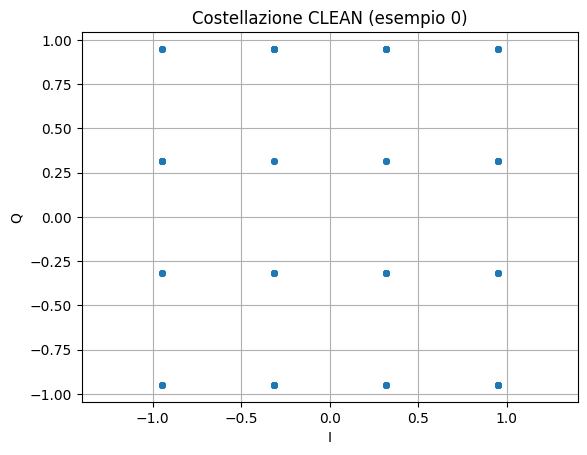

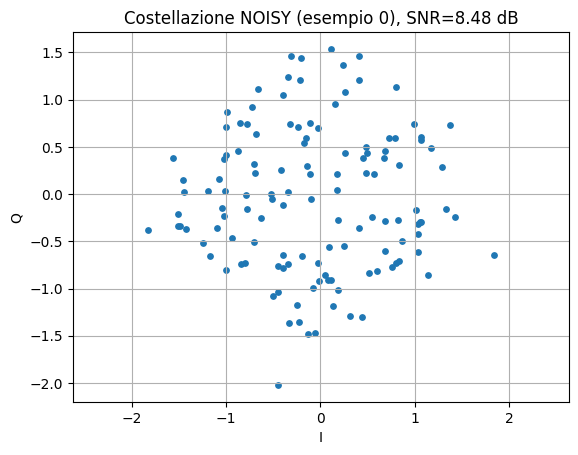

In [4]:
x
import numpy as np

i = 0
iqc = to_complex(dataset["iq_clean"][i])
iqn = to_complex(dataset["iq_noisy"][i])

plt.figure()
plt.scatter(np.real(iqc), np.imag(iqc), s=15)
plt.title(f"Costellazione CLEAN (esempio {i})")
plt.xlabel("I")
plt.ylabel("Q")
plt.axis("equal")
plt.grid(True)
plt.show()

plt.figure()
plt.scatter(np.real(iqn), np.imag(iqn), s=15)
plt.title(f"Costellazione NOISY (esempio {i}), SNR={dataset['snr_db'][i]:.2f} dB")
plt.xlabel("I")
plt.ylabel("Q")
plt.axis("equal")
plt.grid(True)
plt.show()